# Semantic Regression — Cosine Run: Cross-Patient Summary

Reads all `*cosine*` run folders from `results/semantic_regression/`, loads `per_time_scores.csv` and PKL files, and produces:

1. Per-time significance testing (observed vs shuffled null at every time bin)
2. Which embeddings are significantly above chance, when, and for how long
3. Which embedding produces the best metrics across time

**Significance method:** Linear mixed-effects model (LMM) with per-bin fixed effects and random intercept per patient. One-sided test of estimated marginal mean > 0. FDR (Benjamini-Hochberg) correction across bins per (embedding, metric).

## Cell 1 — Imports & Config

In [98]:
import sys
import glob
import json
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Add main/ to path so we can import report package ──────────────────────
MAIN_DIR = pathlib.Path('..').resolve()
if str(MAIN_DIR) not in sys.path:
    sys.path.insert(0, str(MAIN_DIR))

from report.loader import load_patient_from_pkl
from report.config import EMBEDDING_NAMES, SEM_MODELS, VIS_MODELS

# ── Constants ───────────────────────────────────────────────────────────────
BIN_SIZE = 100   # ms per time bin
ALPHA    = 0.001
CACHE_PATH = MAIN_DIR / 'notebooks' / 'cache_null_means.csv'

# Consistent color palette: semantic = warm tones, visual = cool tones
_palette = sns.color_palette('tab10', 6)
EMB_COLORS = dict(zip(EMBEDDING_NAMES, _palette))

# Metric display config
METRICS = [
    ('r2',        'r2_mean',             'R²',                      'R² (above chance)'),
    ('word',      'word_balanced_acc',   'Word Balanced Acc',       'Word Acc − Chance'),
    ('category',  'category_balanced_acc','Category Balanced Acc',  'Cat Acc − Chance'),
]

# ── Pairwise embedding comparisons ──────────────────────────────────────────
# Each entry (A, B) tests H1: effect_A > effect_B at each time bin.
# Set to None to run all pairwise combinations.
COMPARE_PAIRS = [
    ('GloVe',      'DINOv2'),
    ('GloVe',      'SimCLR'),
    #('FastText',   'DINOv2'),
    ('Word2Vec',   'DINOv2'),
    ('Word2Vec',   'SimCLR'),
    #('ConceptNet', 'DINOv2'),
]

print(f"Main dir: {MAIN_DIR}")
print(f"Embeddings: {EMBEDDING_NAMES}")
print(f"Semantic: {SEM_MODELS}  |  Visual: {VIS_MODELS}")
print(f"Comparison pairs: {COMPARE_PAIRS}")


Main dir: D:\OneDrive - Northwestern University\PycharmProjects\Speech\main
Embeddings: ['GloVe', 'FastText', 'Word2Vec', 'ConceptNet', 'DINOv2', 'SimCLR']
Semantic: {'FastText', 'ConceptNet', 'GloVe', 'Word2Vec'}  |  Visual: {'DINOv2', 'SimCLR'}
Comparison pairs: [('GloVe', 'DINOv2'), ('GloVe', 'SimCLR'), ('Word2Vec', 'DINOv2'), ('Word2Vec', 'SimCLR')]


## Cell 2 — Load per_time_scores.csv (All Patients, All Cosine Runs)

In [85]:
RESULTS_DIR = MAIN_DIR / 'results' / 'semantic_regression'
run_folders = sorted(glob.glob(str(RESULTS_DIR / '*cosine*') + '/'))
print(f"Found {len(run_folders)} cosine run folder(s):")
for r in run_folders:
    print(f"  {pathlib.Path(r).name}")

pts_frames = []
for run_path in run_folders:
    run_id = pathlib.Path(run_path).name
    csv_files = glob.glob(str(pathlib.Path(run_path) / '*' / 'per_time_scores.csv'))
    for csv_path in sorted(csv_files):
        df_tmp = pd.read_csv(csv_path)
        df_tmp['run_id'] = run_id
        pts_frames.append(df_tmp)

df_pts = pd.concat(pts_frames, ignore_index=True)
df_pts['time_ms'] = df_pts['bin_index'] * BIN_SIZE

# ── Report ──────────────────────────────────────────────────────────────────
patients   = sorted(df_pts['patient'].unique())
embeddings = [e for e in EMBEDDING_NAMES if e in df_pts['embedding'].unique()]
time_bins  = sorted(df_pts['bin_index'].unique())
print(f"\nLoaded: {len(patients)} patients × {len(embeddings)} embeddings × {len(time_bins)} bins")
print(f"Patients : {patients}")
print(f"Time range: {min(time_bins)*BIN_SIZE}–{max(time_bins)*BIN_SIZE} ms")
print(f"\nColumns: {list(df_pts.columns)}")
df_pts.head(3)

Found 1 cosine run folder(s):
  2026-03-27_12-35-02_KRR_cosine_50ep

Loaded: 12 patients × 6 embeddings × 80 bins
Patients : ['AA', 'AP', 'AZ', 'CP', 'DR', 'EH', 'EM', 'LH', 'MM', 'RB', 'VB', 'WBH']
Time range: 0–7900 ms

Columns: ['patient', 'embedding', 'bin_index', 'r2_mean', 'r2_std', 'chance_mean', 'word_balanced_acc', 'category_balanced_acc', 'word_f1', 'category_f1', 'run_id', 'time_ms']


,patient,embedding,bin_index,r2_mean,r2_std,chance_mean,word_balanced_acc,category_balanced_acc,word_f1,category_f1,run_id,time_ms
0,AA,GloVe,0,-0.028275,0.010376,-0.033233,0.016645,0.165700,0.008816,0.136111,2026-03-27_12-35-02_KRR_cosine_50ep,0
1,AA,GloVe,1,-0.022153,0.011176,-0.026133,0.016580,0.168525,0.008098,0.137250,2026-03-27_12-35-02_KRR_cosine_50ep,100
2,AA,GloVe,2,-0.020599,0.010042,-0.022564,0.018385,0.175781,0.007778,0.143517,2026-03-27_12-35-02_KRR_cosine_50ep,200


## Cell 3 — PKL Loading: Extract Per-Patient Per-Bin Means

For each patient PKL, we extract `(n_epochs, n_bins)` arrays for:
- `cat_obs` / `cat_null` — category balanced accuracy observed vs shuffled null
- `word_obs` / `word_null` — word balanced accuracy observed vs shuffled null

We compute per-patient per-bin **means** across the 50 CV epochs (collapsing the non-independent resamples into a single summary per patient/bin).

> Loading 12 PKL files takes ~10–20 min. Results are cached to `cache_null_means.csv` — delete this file to force a reload.

In [86]:
def load_and_extract_pkl_data(run_folders, patients, embeddings):
    """Load PKLs and return df_null with per-patient per-bin means."""
    null_records = []

    for run_path in run_folders:
        run_id = pathlib.Path(run_path).name
        for patient in patients:
            pkl_path = pathlib.Path(run_path) / patient / 'semantic_regression_results.pkl'
            if not pkl_path.exists():
                print(f"  [skip] {patient}: no PKL found")
                continue

            print(f"  Loading {patient}...", end=' ', flush=True)
            pkl_data = load_patient_from_pkl(str(pkl_path))
            if pkl_data is None:
                print("SKIPPED (too large or error)")
                continue
            print(f"OK ({len(pkl_data)} embeddings)")

            for emb in embeddings:
                if emb not in pkl_data:
                    continue
                d = pkl_data[emb]
                cat_obs  = np.array(d['cat_obs'])   # (n_epochs, n_bins)
                cat_null = np.array(d['cat_null'])
                word_obs  = np.array(d['word_obs'])
                word_null = np.array(d['word_null'])
                n_bins = cat_obs.shape[1]

                for b in range(n_bins):
                    # Per-patient means across epochs
                    null_records.append({
                        'run_id':        run_id,
                        'patient':       patient,
                        'embedding':     emb,
                        'bin_index':     b,
                        'time_ms':       b * BIN_SIZE,
                        'cat_obs_mean':  float(cat_obs[:, b].mean()),
                        'cat_null_mean': float(cat_null[:, b].mean()),
                        'word_obs_mean': float(word_obs[:, b].mean()),
                        'word_null_mean':float(word_null[:, b].mean()),
                    })

    return pd.DataFrame(null_records)


# ── Load (with caching) ──────────────────────────────────────────────────────
if CACHE_PATH.exists():
    print(f"Loading from cache: {CACHE_PATH}")
    df_null = pd.read_csv(CACHE_PATH)
    print(f"Cache loaded: {len(df_null)} rows")
else:
    print("No cache found — loading PKL files (this may take 10–20 min)...")
    df_null = load_and_extract_pkl_data(run_folders, patients, embeddings)
    df_null.to_csv(CACHE_PATH, index=False)
    print(f"\nSaved cache to {CACHE_PATH}")

print(f"\ndf_null shape: {df_null.shape}")

# ── Trim to shortest patient (consistent time axis) ───────────────────────────
_max_bin_pts  = df_pts.groupby('patient')['bin_index'].max().min()
_max_bin_null = df_null.groupby('patient')['bin_index'].max().min()
MAX_BIN_INDEX = int(min(_max_bin_pts, _max_bin_null))

df_pts  = df_pts[df_pts['bin_index']  <= MAX_BIN_INDEX].copy()
df_null = df_null[df_null['bin_index'] <= MAX_BIN_INDEX].copy()

# Refresh time_bins so downstream cells see the trimmed range
time_bins = sorted(df_pts['bin_index'].unique())
print(f"Trimmed to {MAX_BIN_INDEX + 1} bins (0–{MAX_BIN_INDEX * BIN_SIZE} ms) — shortest-patient constraint")
print(f"df_pts rows: {len(df_pts)},  df_null rows: {len(df_null)}")
df_null.head(3)


Loading from cache: D:\OneDrive - Northwestern University\PycharmProjects\Speech\main\notebooks\cache_null_means.csv
Cache loaded: 3942 rows

df_null shape: (3942, 9)
Trimmed to 50 bins (0–4900 ms) — shortest-patient constraint
df_pts rows: 3600,  df_null rows: 3600


,run_id,patient,embedding,bin_index,time_ms,cat_obs_mean,cat_null_mean,word_obs_mean,word_null_mean
0,2026-03-27_12-35-02_KRR_cosine_50ep,AA,GloVe,0,0,0.165700,0.165538,0.016645,0.015743
1,2026-03-27_12-35-02_KRR_cosine_50ep,AA,GloVe,1,100,0.168525,0.168140,0.016580,0.014940
2,2026-03-27_12-35-02_KRR_cosine_50ep,AA,GloVe,2,200,0.175781,0.171034,0.018385,0.017688


## Cell 4 — Group-Level Significance (Mixed-Effects Model)

For each (embedding, metric), fit a linear mixed-effects model:

    effect ~ 0 + C(bin_index),  groups = patient

This estimates the population-level effect at each time bin while accounting for between-patient variability via a random intercept. One-sided test of estimated marginal mean > 0 per bin. FDR correction across bins per (embedding, metric).

In [87]:
def compute_group_significance(df_null, df_pts, embeddings):
    """
    Compute group-level significance using a linear mixed-effects model.

    For each (embedding, metric), fits:
        effect ~ 0 + C(bin_index), groups=patient
    with a random intercept. One-sided test of estimated mean > 0 per bin.
    FDR correction across bins per (embedding, metric).

    Returns
    -------
    sig_df : pd.DataFrame
        One row per (embedding, bin_index, metric) with columns:
        effect, se, ci_lower, ci_upper, mean_obs, mean_null, sem_obs,
        n_patients, p_raw, p_fdr, significant, tau2, method
    """
    # ── Build long-form effect table ────────────────────────────────────────
    effect_rows = []

    for emb in embeddings:
        emb_null = df_null[df_null['embedding'] == emb]
        emb_pts  = df_pts[df_pts['embedding'] == emb]

        # Category & Word from PKL null
        for metric_key, obs_col, null_col in [
            ('category', 'cat_obs_mean',  'cat_null_mean'),
            ('word',     'word_obs_mean', 'word_null_mean'),
        ]:
            for _, row in emb_null.iterrows():
                effect_rows.append({
                    'patient':   row['patient'],
                    'embedding': emb,
                    'bin_index': int(row['bin_index']),
                    'time_ms':   int(row['bin_index']) * BIN_SIZE,
                    'metric':    metric_key,
                    'obs':       float(row[obs_col]),
                    'null':      float(row[null_col]),
                    'effect':    float(row[obs_col] - row[null_col]),
                })

        # R² from per_time_scores.csv
        for _, row in emb_pts.iterrows():
            effect_rows.append({
                'patient':   row['patient'],
                'embedding': emb,
                'bin_index': int(row['bin_index']),
                'time_ms':   int(row['bin_index']) * BIN_SIZE,
                'metric':    'r2',
                'obs':       float(row['r2_mean']),
                'null':      float(row['chance_mean']),
                'effect':    float(row['r2_mean'] - row['chance_mean']),
            })

    long_df = pd.DataFrame(effect_rows)

    # ── Fit LMM per (embedding, metric) ─────────────────────────────────────
    records = []

    for (emb, metric), subset in long_df.groupby(['embedding', 'metric']):
        subset = subset.sort_values(['patient', 'bin_index']).copy()

        try:
            model = smf.mixedlm(
                "effect ~ 0 + C(bin_index)",
                data=subset,
                groups=subset["patient"],
            )
            result = model.fit(reml=True)
            tau2 = float(result.cov_re.iloc[0, 0])
            ci_df = result.conf_int()
        except Exception as e:
            raise RuntimeError(f"LMM failed for {emb}/{metric}: {e}")

        for param_name in result.fe_params.index:
            # Parse bin index: 'C(bin_index)[0]' or 'C(bin_index)[T.0]'
            b_str = param_name.rsplit('[', 1)[1].rstrip(']')
            if b_str.startswith('T.'):
                b_str = b_str[2:]
            b = int(float(b_str))

            estimate = float(result.fe_params[param_name])
            se = float(result.bse[param_name])
            p_two = float(result.pvalues[param_name])
            # One-sided: H1: effect > 0
            p_one = p_two / 2 if estimate > 0 else 1.0 - p_two / 2
            ci_lo = float(ci_df.loc[param_name].iloc[0])
            ci_hi = float(ci_df.loc[param_name].iloc[1])

            bin_data = subset[subset['bin_index'] == b]
            records.append({
                'embedding':  emb,
                'bin_index':  b,
                'time_ms':    b * BIN_SIZE,
                'metric':     metric,
                'effect':     estimate,
                'se':         se,
                'ci_lower':   ci_lo,
                'ci_upper':   ci_hi,
                'mean_obs':   float(bin_data['obs'].mean()),
                'mean_null':  float(bin_data['null'].mean()),
                'sem_obs':    float(bin_data['obs'].std(ddof=1) / np.sqrt(len(bin_data))),
                'n_patients': len(bin_data),
                'p_raw':      p_one,
                'tau2':       tau2,
                'method':     'lmm',
            })

    df = pd.DataFrame(records)

    # FDR correction across bins per (embedding, metric)
    fdr_corrected = []
    for (emb, metric), grp in df.groupby(['embedding', 'metric']):
        p_vals = grp['p_raw'].values
        if len(p_vals) < 2:
            fdr = p_vals.copy()
        else:
            _, fdr, _, _ = multipletests(p_vals, alpha=ALPHA, method='fdr_bh')
        grp = grp.copy()
        grp['p_fdr'] = fdr
        fdr_corrected.append(grp)

    df = pd.concat(fdr_corrected, ignore_index=True)
    df['significant'] = df['p_fdr'] < ALPHA
    return df.sort_values(['embedding', 'metric', 'bin_index']).reset_index(drop=True)


sig_df = compute_group_significance(df_null, df_pts, embeddings)
print(f"sig_df shape: {sig_df.shape}")
n_sig = sig_df['significant'].sum()
print(f"Significant (p_fdr < {ALPHA}): {n_sig}/{len(sig_df)} cells")
methods = sig_df['method'].value_counts()
print(f"Methods used: {methods.to_dict()}")
print(f"Mean τ² (patient variance): {sig_df['tau2'].mean():.6f}")
sig_df.groupby(['metric', 'embedding'])['significant'].sum().unstack('embedding')


sig_df shape: (900, 17)
Significant (p_fdr < 0.001): 279/900 cells
Methods used: {'lmm': 900}
Mean τ² (patient variance): 0.000210


embedding,ConceptNet,DINOv2,FastText,GloVe,SimCLR,Word2Vec
metric,,,,,,
category,20,17,17,19,20,17
r2,13,11,12,13,12,12
word,22,16,13,14,16,15


## Cell 5 — Figure 1: Time Series Per Embedding (3 rows × 6 cols)

Shows each metric (R², word accuracy, category accuracy) as **above-chance deviation** over time for each embedding separately. Individual patient lines + LMM estimated mean with 95% CI + significance ticks.

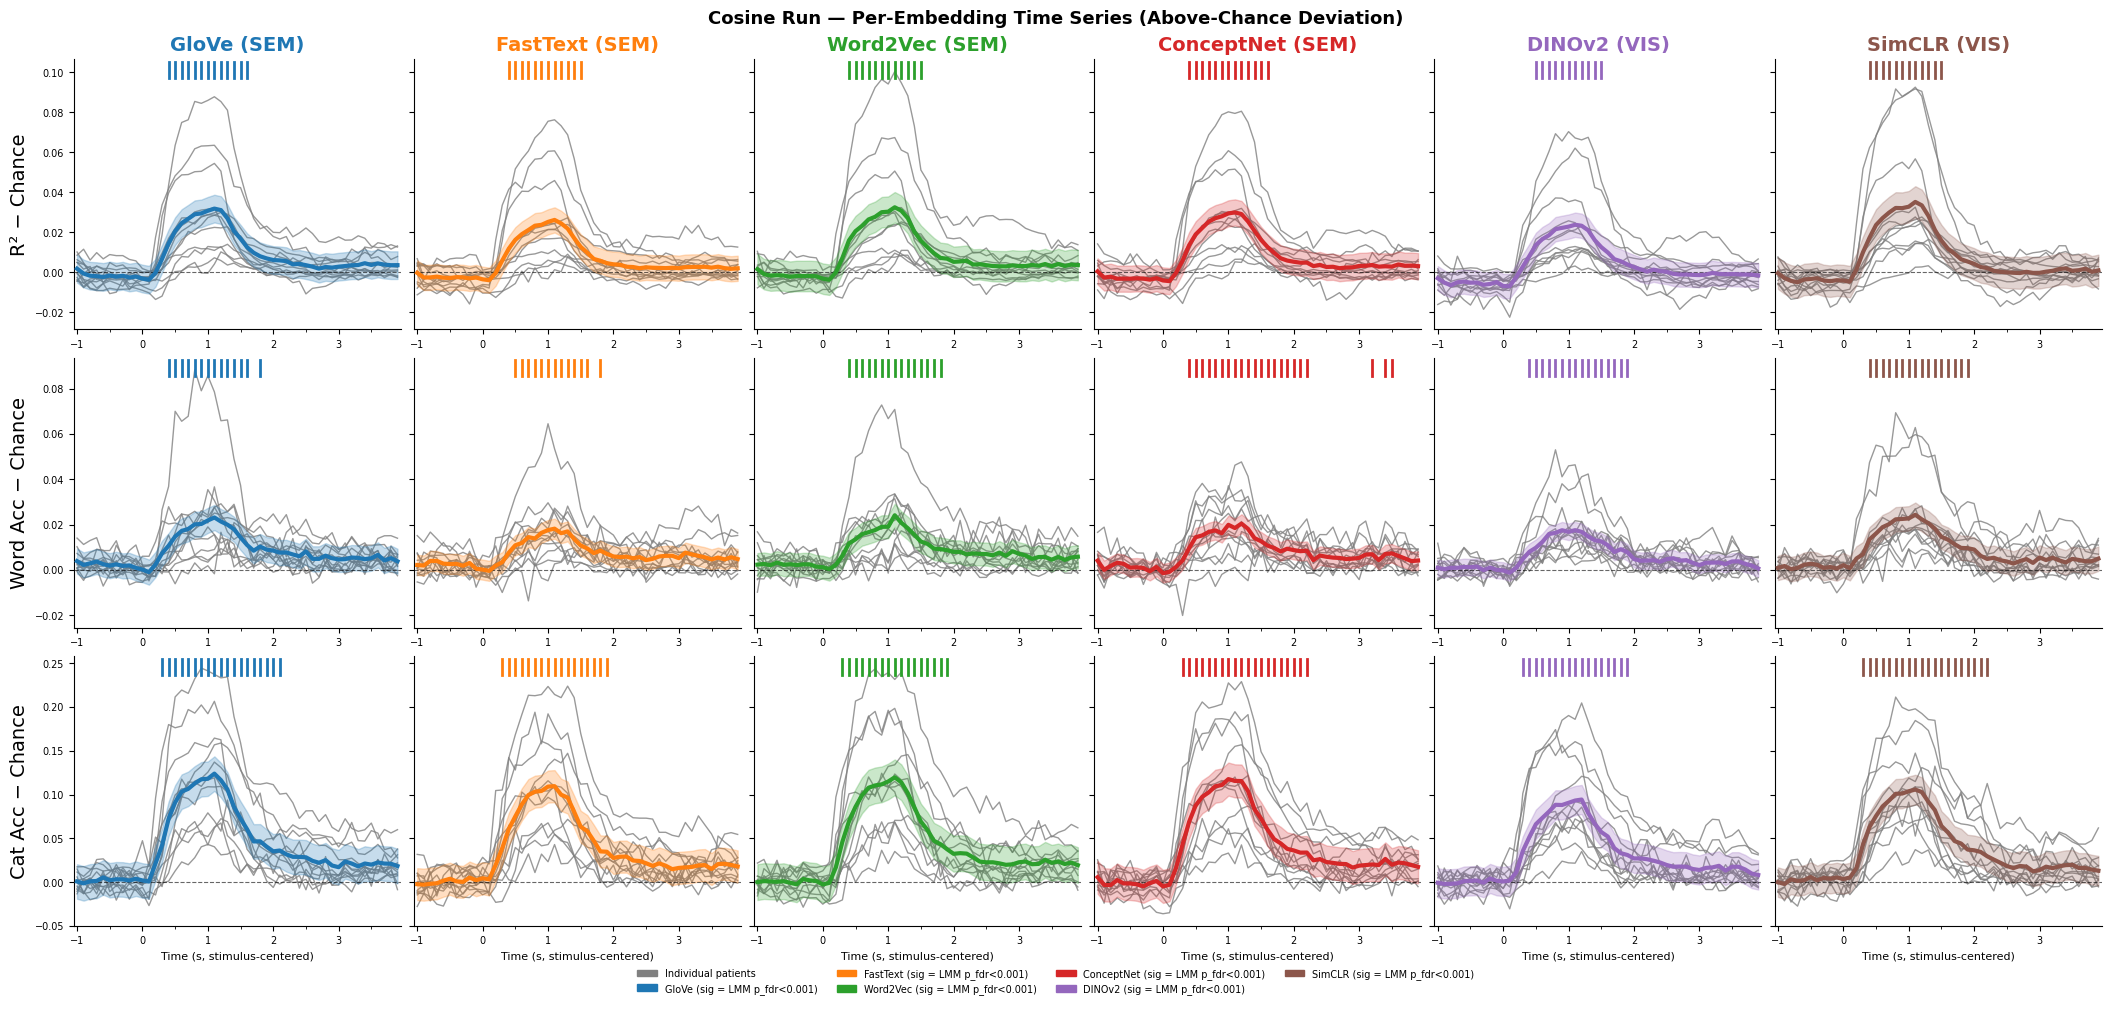

Saved: fig1_timeseries_per_embedding.png


In [104]:
def _get_per_patient_effect(df_pts, df_null, embeddings, metric_key):
    """
    Return dict[emb] -> dict[patient] -> array(n_bins) of (obs - null).
    For R²: uses df_pts; for word/category: uses df_null.
    """
    result = {emb: {} for emb in embeddings}

    if metric_key == 'r2':
        for emb in embeddings:
            sub = df_pts[df_pts['embedding'] == emb].sort_values(['patient', 'bin_index'])
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                result[emb][pat] = (g['r2_mean'].values - g['chance_mean'].values)
    else:
        obs_col  = 'cat_obs_mean'  if metric_key == 'category' else 'word_obs_mean'
        null_col = 'cat_null_mean' if metric_key == 'category' else 'word_null_mean'
        for emb in embeddings:
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                result[emb][pat] = (g[obs_col].values - g[null_col].values)
    return result


metric_labels = [
    ('r2',       'R² − Chance'),
    ('word',     'Word Acc − Chance'),
    ('category', 'Cat Acc − Chance'),
]
n_metrics = len(metric_labels)
n_embs    = len(embeddings)

PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

fig, axes = plt.subplots(
    n_metrics, n_embs,
    figsize=(3.5 * n_embs, 3.2 * n_metrics),
    sharey='row',
    constrained_layout=True,
)
fig.suptitle('Cosine Run — Per-Embedding Time Series (Above-Chance Deviation)', fontsize=13, fontweight='bold')

time_vals_ms = np.array(sorted(df_pts['bin_index'].unique())) * BIN_SIZE
time_vals = (time_vals_ms - PRE_STIM_MS) / MS_PER_SEC

for row_idx, (metric_key, ylabel) in enumerate(metric_labels):
    per_patient = _get_per_patient_effect(df_pts, df_null, embeddings, metric_key)
    metric_sig  = sig_df[(sig_df['metric'] == metric_key)]

    for col_idx, emb in enumerate(embeddings):
        ax = axes[row_idx, col_idx]
        color = EMB_COLORS[emb]

        # Individual patient lines
        pat_data = per_patient.get(emb, {})
        for pat, eff in pat_data.items():
            t = time_vals[:len(eff)]
            ax.plot(t, eff, color='grey', alpha=0.8, lw=1, zorder=1)

        # Group estimated effect ± 95% CI from LMM
        lmm = metric_sig[metric_sig['embedding'] == emb].sort_values('bin_index')
        if len(lmm):
            lmm_t = (lmm['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
            ax.fill_between(lmm_t, lmm['ci_lower'].values, lmm['ci_upper'].values,
                            alpha=0.25, color=color, zorder=2)
            ax.plot(lmm_t, lmm['effect'].values, color=color, lw=3, zorder=3, label=emb)

        # Chance line
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6)

        # Significance ticks at top
        emb_sig = metric_sig[(metric_sig['embedding'] == emb) & (metric_sig['significant'])]
        for t_sig in emb_sig['time_ms'].values:
            t_sig_s = (t_sig - PRE_STIM_MS) / MS_PER_SEC
            ax.axvline(t_sig_s, ymin=0.93, ymax=0.99, color=color, lw=2, zorder=5)

        ax.set_xlim(time_vals[0] - half_bin_s, time_vals[-1] + half_bin_s)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=7)

        model_type = 'SEM' if emb in SEM_MODELS else 'VIS'
        if row_idx == 0:
            ax.set_title(f"{emb} ({model_type})", fontsize=14, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        if row_idx == n_metrics - 1:
            ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)

        ax.spines[['top', 'right']].set_visible(False)

# Add significance legend
sig_patch = mpatches.Patch(color='grey', label='Individual patients')
fig.legend(
    handles=[sig_patch] + [
        mpatches.Patch(color=EMB_COLORS[e], label=f"{e} (sig = LMM p_fdr<{ALPHA})")
        for e in embeddings
    ],
    loc='lower center', ncol=4, fontsize=7, frameon=False,
    bbox_to_anchor=(0.5, -0.04)
)

plt.savefig(MAIN_DIR / 'notebooks' / 'fig1_timeseries_per_embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_timeseries_per_embedding.png")

## Cell 6 — Figure 2: All Embeddings Overlaid (3-Panel)

Direct embedding comparison: all 6 overlaid for each metric. LMM estimated effect ± 95% CI. Significance indicated as colored horizontal bars at the top of each panel.

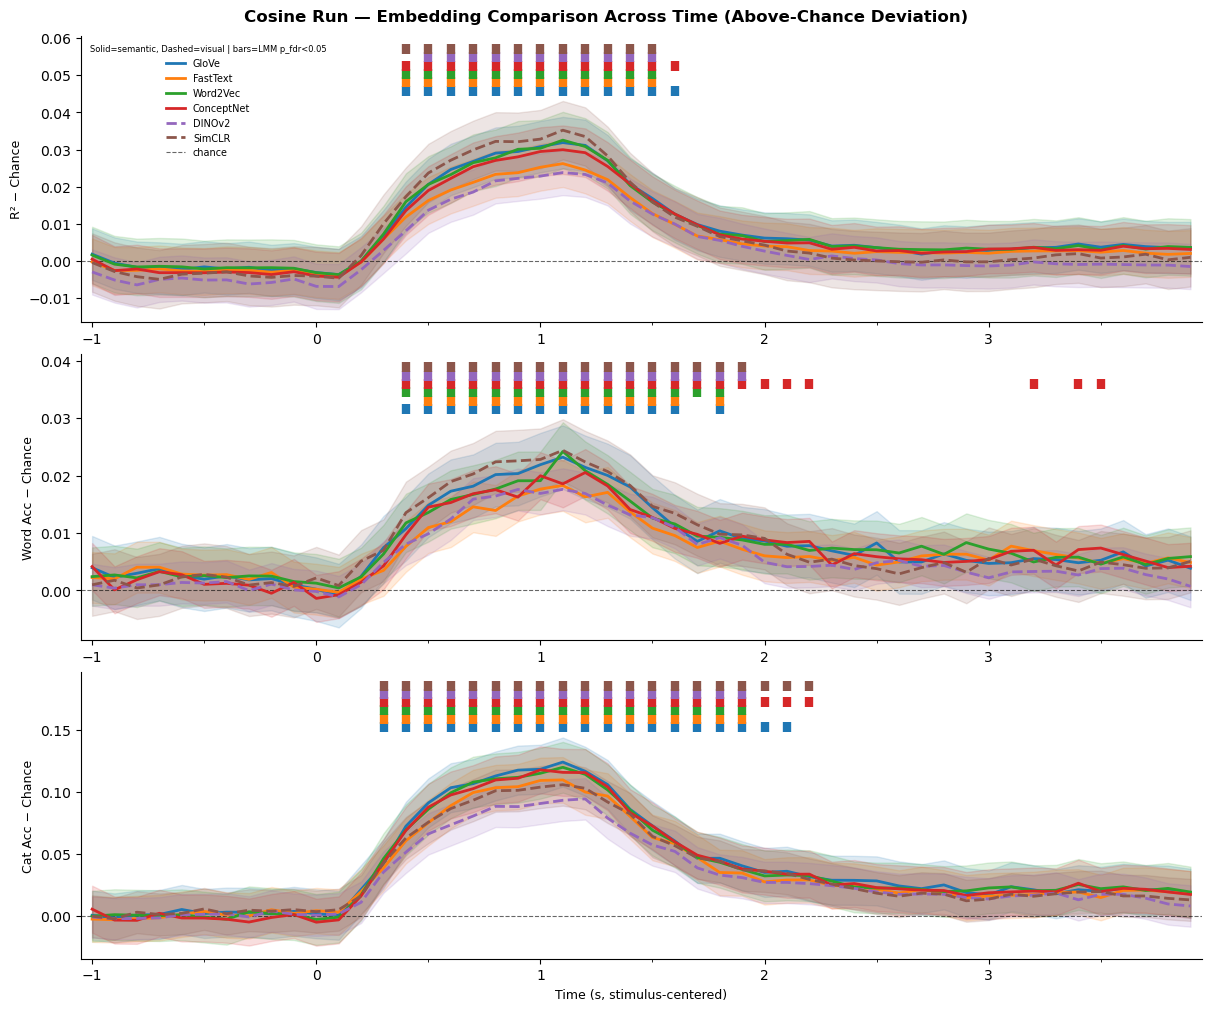

Saved: fig2_embedding_comparison.png


In [105]:
PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.suptitle('Cosine Run — Embedding Comparison Across Time (Above-Chance Deviation)', fontsize=12, fontweight='bold')

for ax_idx, (metric_key, ylabel) in enumerate(metric_labels):
    ax = axes[ax_idx]
    metric_sig = sig_df[sig_df['metric'] == metric_key]

    # Determine significance bar y positions from LMM CI bounds
    y_max_data = metric_sig['ci_upper'].max() if len(metric_sig) else 0.1
    y_min_data = metric_sig['ci_lower'].min() if len(metric_sig) else -0.05
    y_range = y_max_data - y_min_data
    sig_bar_base = y_max_data + y_range * 0.05
    sig_bar_gap  = y_range * 0.04

    for i_emb, emb in enumerate(embeddings):
        color = EMB_COLORS[emb]
        lmm = metric_sig[metric_sig['embedding'] == emb].sort_values('bin_index')
        if not len(lmm):
            continue

        lmm_t = (lmm['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
        ax.fill_between(lmm_t, lmm['ci_lower'].values, lmm['ci_upper'].values,
                        alpha=0.15, color=color)
        ls = '-' if emb in SEM_MODELS else '--'
        ax.plot(lmm_t, lmm['effect'].values, color=color, lw=2, ls=ls, label=emb, zorder=3)

        # Significance bar (horizontal colored line at top)
        emb_sig = lmm[lmm['significant']]
        y_bar = sig_bar_base + i_emb * sig_bar_gap
        if len(emb_sig) > 0:
            sig_times_s = (emb_sig['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC
            ax.scatter(
                sig_times_s,
                np.full(len(emb_sig), y_bar),
                color=color, marker='|', s=50, lw=6, zorder=4
            )

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.6, label='chance')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(time_vals[0] - half_bin_s, time_vals[-1] + half_bin_s)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.spines[['top', 'right']].set_visible(False)

    if ax_idx == 2:
        ax.set_xlabel('Time (s, stimulus-centered)', fontsize=9)

    if ax_idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles, labels,
            loc='upper left', fontsize=7, frameon=False,
            title='Solid=semantic, Dashed=visual | bars=LMM p_fdr<0.05',
            title_fontsize=6
        )

plt.savefig(MAIN_DIR / 'notebooks' / 'fig2_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_embedding_comparison.png")

## Cell 7 — Figure 3: Significance Heatmap (Embeddings × Time)

Color = −log₁₀(p_fdr). Makes onset, duration, and which embeddings dominate instantly visible.

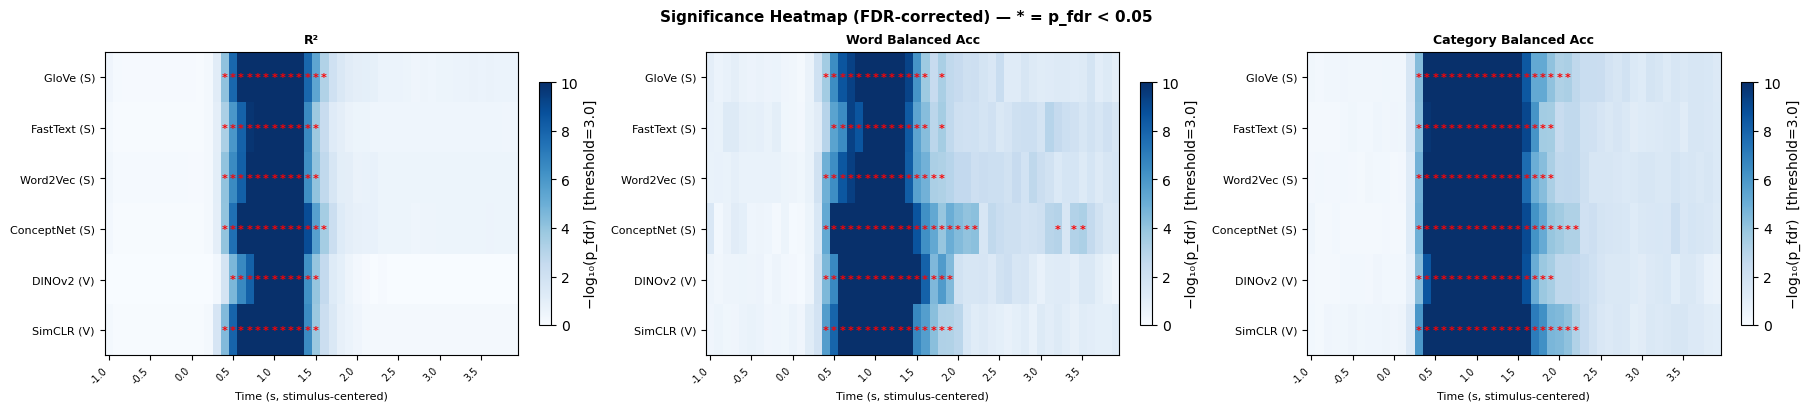

Saved: fig3_significance_heatmap.png


In [90]:
def _sig_heatmap(ax, sig_df, metric_key, embeddings, title):
    sub = sig_df[sig_df['metric'] == metric_key]
    bins = sorted(sub['bin_index'].unique())
    n_emb = len(embeddings)
    n_bin = len(bins)

    PRE_STIM_MS = 1000
    MS_PER_SEC = 1000.0

    # Build matrix: rows=embeddings, cols=bins, value = -log10(p_fdr)
    mat = np.zeros((n_emb, n_bin))
    sig_mask = np.zeros((n_emb, n_bin), dtype=bool)
    for i, emb in enumerate(embeddings):
        for j, b in enumerate(bins):
            row = sub[(sub['embedding'] == emb) & (sub['bin_index'] == b)]
            if len(row):
                p = float(row['p_fdr'].values[0])
                mat[i, j] = -np.log10(max(p, 1e-10))
                sig_mask[i, j] = p < ALPHA

    vmax = max(mat.max(), -np.log10(ALPHA) + 0.5)
    im = ax.imshow(
        mat, aspect='auto', cmap='Blues',
        vmin=0, vmax=vmax,
        origin='upper',
    )

    # Star overlay for significant cells
    for i in range(n_emb):
        for j in range(n_bin):
            if sig_mask[i, j]:
                ax.text(j, i, '*', ha='center', va='center', fontsize=8, color='red', fontweight='bold')

    # Axis formatting
    ax.set_yticks(range(n_emb))
    ax.set_yticklabels([
        f"{e} ({'S' if e in SEM_MODELS else 'V'})"
        for e in embeddings
    ], fontsize=8)

    tick_step = max(1, n_bin // 10)
    ax.set_xticks(range(0, n_bin, tick_step))
    ax.set_xticklabels(
        [f"{((bins[j] * BIN_SIZE) - PRE_STIM_MS) / MS_PER_SEC:.1f}" for j in range(0, n_bin, tick_step)],
        fontsize=7, rotation=45, ha='right'
    )
    ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')

    # Threshold line
    thresh_val = -np.log10(ALPHA)
    plt.colorbar(im, ax=ax, label=f'−log₁₀(p_fdr)  [threshold={thresh_val:.1f}]', shrink=0.8)


fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle('Significance Heatmap (FDR-corrected) — * = p_fdr < 0.05', fontsize=11, fontweight='bold')

_sig_heatmap(axes[0], sig_df, 'r2',       embeddings, 'R²')
_sig_heatmap(axes[1], sig_df, 'word',     embeddings, 'Word Balanced Acc')
_sig_heatmap(axes[2], sig_df, 'category', embeddings, 'Category Balanced Acc')

plt.savefig(MAIN_DIR / 'notebooks' / 'fig3_significance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_significance_heatmap.png")

## Cell 8 — Figure 4: Onset, Peak & Duration of Significant Windows

For each (embedding, metric): shows the **longest consecutive significant window** as a horizontal span, with peak effect time marked.

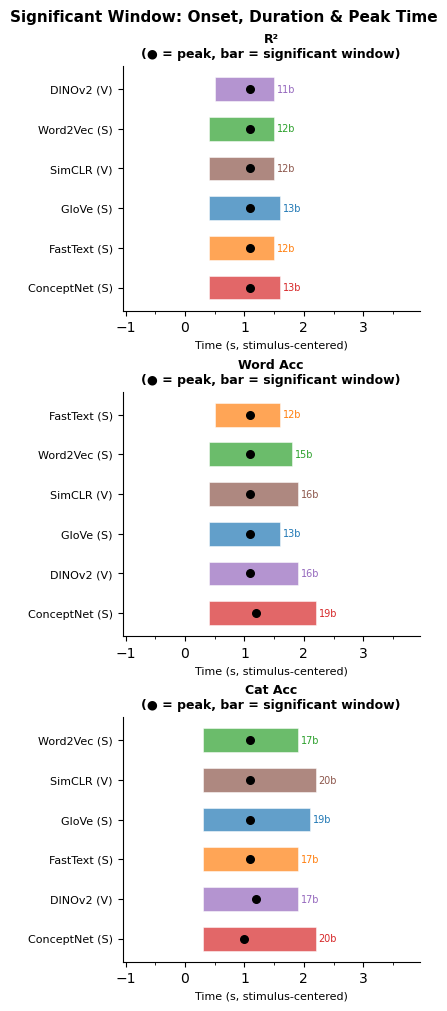

Saved: fig4_onset_duration.png


In [107]:
def get_longest_sig_run(sig_series, time_series):
    """
    Find the longest consecutive run of True values in sig_series.
    Returns (onset, offset, duration_bins) or (None, None, 0) if none.
    """
    best = (None, None, 0)
    run_start = None
    run_len = 0
    for t, s in zip(time_series, sig_series):
        if s:
            if run_start is None:
                run_start = t
            run_len += 1
            run_end = t
        else:
            if run_len > best[2]:
                best = (run_start, run_end, run_len)
            run_start = None
            run_len = 0
    if run_len > best[2]:
        best = (run_start, run_end, run_len)
    return best


PRE_STIM_MS = 1000
MS_PER_SEC = 1000.0
half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

summary_rows = []
for (emb, metric), grp in sig_df.groupby(['embedding', 'metric']):
    grp = grp.sort_values('bin_index')
    peak_idx = grp['effect'].idxmax()
    peak_ms  = grp.loc[peak_idx, 'time_ms']
    onset, offset, n_bins = get_longest_sig_run(
        grp['significant'].values,
        grp['time_ms'].values
    )
    summary_rows.append({
        'embedding':     emb,
        'metric':        metric,
        'onset_ms':      onset,
        'offset_ms':     offset,
        'n_sig_bins':    n_bins,
        'peak_ms':       peak_ms,
        'peak_effect':   float(grp.loc[peak_idx, 'effect']),
        'peak_se':       float(grp.loc[peak_idx, 'se']),
        'peak_ci_lower': float(grp.loc[peak_idx, 'ci_lower']),
        'peak_ci_upper': float(grp.loc[peak_idx, 'ci_upper']),
        'peak_obs':      float(grp.loc[peak_idx, 'mean_obs']),
        'peak_null':     float(grp.loc[peak_idx, 'mean_null']),
        'peak_sem':      float(grp.loc[peak_idx, 'sem_obs']),
        'tau2':          float(grp['tau2'].iloc[0]),
    })
summary_df = pd.DataFrame(summary_rows)

# ── Figure 4 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(4, 10), constrained_layout=True)
fig.suptitle('Significant Window: Onset, Duration & Peak Time', fontsize=11, fontweight='bold')

time_vals_s = (np.array(sorted(df_pts['bin_index'].unique())) * BIN_SIZE - PRE_STIM_MS) / MS_PER_SEC

for ax_idx, metric_key in enumerate(['r2', 'word', 'category']):
    ax = axes[ax_idx]
    msub = summary_df[summary_df['metric'] == metric_key].copy()

    # Convert trial-relative ms to stimulus-centered seconds for plotting
    msub['onset_s']  = (msub['onset_ms'] - PRE_STIM_MS) / MS_PER_SEC
    msub['offset_s'] = (msub['offset_ms'] - PRE_STIM_MS) / MS_PER_SEC
    msub['peak_s']   = (msub['peak_ms'] - PRE_STIM_MS) / MS_PER_SEC

    # Sort by onset (None -> place at end)
    msub['_sort'] = msub['onset_s'].fillna(9999)
    msub = msub.sort_values('_sort')

    y_positions = range(len(msub))
    for y_pos, (_, row) in zip(y_positions, msub.iterrows()):
        emb   = row['embedding']
        color = EMB_COLORS[emb]
        onset  = row['onset_s']
        offset = row['offset_s']

        if pd.notna(onset) and pd.notna(offset):
            # Draw horizontal significance span
            ax.barh(
                y_pos, offset - onset, left=onset,
                height=0.6, color=color, alpha=0.7, edgecolor='white', lw=0.5
            )
            # Peak marker
            ax.scatter(row['peak_s'], y_pos, color='black', s=30, zorder=5)
            # Duration label
            ax.text(
                offset + 0.05, y_pos, f"{row['n_sig_bins']}b",
                va='center', fontsize=7, color=color
            )
        else:
            ax.text(0.0, y_pos, 'NS', va='center', ha='center', fontsize=8, color='grey')

    metric_titles = {'r2': 'R²', 'word': 'Word Acc', 'category': 'Cat Acc'}
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(
        [f"{r['embedding']} ({'S' if r['embedding'] in SEM_MODELS else 'V'})" for _, r in msub.iterrows()],
        fontsize=8
    )
    ax.set_xlabel('Time (s, stimulus-centered)', fontsize=8)
    ax.set_title(f"{metric_titles[metric_key]}\n(● = peak, bar = significant window)", fontsize=9, fontweight='bold')
    ax.set_xlim(time_vals_s[0] - half_bin_s, time_vals_s[-1] + half_bin_s)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
    ax.spines[['top', 'right']].set_visible(False)

plt.savefig(MAIN_DIR / 'notebooks' / 'fig4_onset_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_onset_duration.png")

## Cell 9 — Figure 5: Peak Performance (Absolute Accuracy)

Bar chart of peak observed accuracy for each embedding, with chance level as reference.

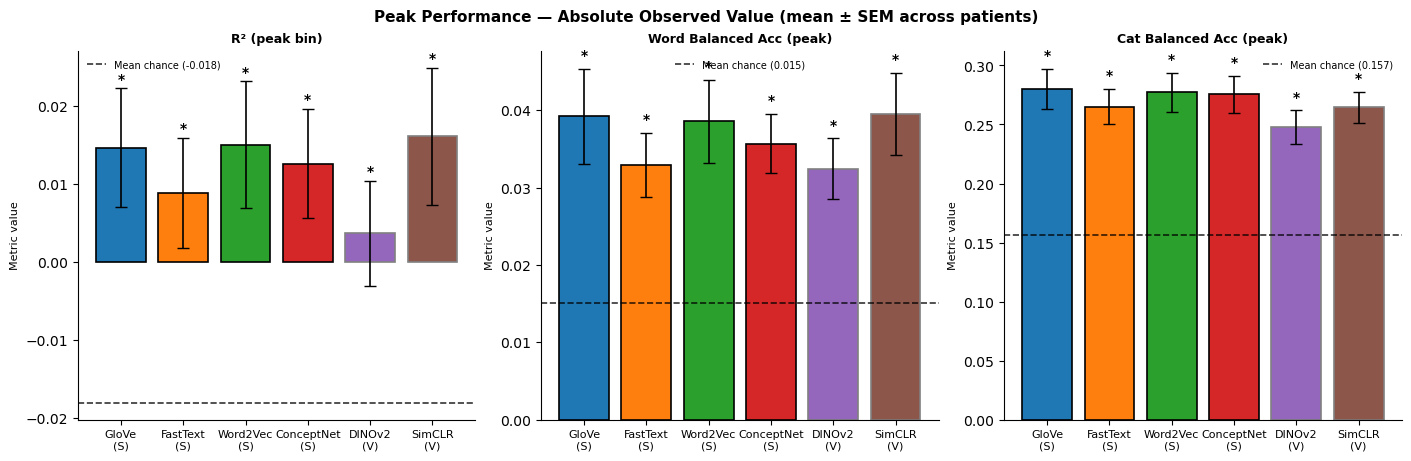

Saved: fig5_peak_performance.png


In [92]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle('Peak Performance — Absolute Observed Value (mean ± SEM across patients)', fontsize=11, fontweight='bold')

metric_titles = {'r2': 'R² (peak bin)', 'word': 'Word Balanced Acc (peak)', 'category': 'Cat Balanced Acc (peak)'}

for ax_idx, metric_key in enumerate(['r2', 'word', 'category']):
    ax = axes[ax_idx]
    msub = summary_df[summary_df['metric'] == metric_key].copy()

    x = np.arange(len(embeddings))
    bar_colors = [EMB_COLORS[e] for e in embeddings]
    edge_colors = ['black' if e in SEM_MODELS else 'grey' for e in embeddings]

    peak_vals  = []
    peak_sems  = []
    null_vals  = []

    for emb in embeddings:
        row = msub[msub['embedding'] == emb]
        if len(row):
            peak_vals.append(row['peak_obs'].values[0])
            peak_sems.append(row['peak_sem'].values[0])
            null_vals.append(row['peak_null'].values[0])
        else:
            peak_vals.append(0)
            peak_sems.append(0)
            null_vals.append(0)

    bars = ax.bar(
        x, peak_vals, color=bar_colors, edgecolor=edge_colors,
        linewidth=1.2, yerr=peak_sems, capsize=4,
        error_kw={'ecolor': 'black', 'elinewidth': 1.2}
    )

    # Chance level (mean across embeddings at that bin)
    mean_chance = np.mean(null_vals)
    ax.axhline(mean_chance, color='black', lw=1.2, ls='--', alpha=0.8, label=f'Mean chance ({mean_chance:.3f})')

    # Significance stars above bars
    for i, emb in enumerate(embeddings):
        emb_sig = sig_df[
            (sig_df['embedding'] == emb) &
            (sig_df['metric'] == metric_key) &
            (sig_df['significant'])
        ]
        if len(emb_sig) > 0:
            ax.text(
                i, peak_vals[i] + peak_sems[i] + (max(peak_vals) * 0.02),
                '*', ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{e}\n({'S' if e in SEM_MODELS else 'V'})" for e in embeddings],
        fontsize=8
    )
    ax.set_title(metric_titles[metric_key], fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Metric value', fontsize=8)

plt.savefig(MAIN_DIR / 'notebooks' / 'fig5_peak_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_peak_performance.png")

## Cell 10 — Summary Statistics Table

In [93]:
print('Note: Figures use stimulus-centered seconds (0 s = stimulus onset); this table remains trial-relative milliseconds.')
print('Statistical method: Linear mixed-effects model with random intercept per patient.\n')

table = summary_df[[
    'embedding', 'metric',
    'peak_effect', 'peak_ci_lower', 'peak_ci_upper', 'peak_ms',
    'onset_ms', 'offset_ms', 'n_sig_bins', 'tau2'
]].copy()

table.columns = [
    'Embedding', 'Metric',
    'Peak Effect', 'CI Lower', 'CI Upper', 'Peak Time (ms)',
    'Onset (ms)', 'Offset (ms)', 'N Sig Bins', 'τ²'
]

# Add model type
table.insert(1, 'Type', table['Embedding'].apply(lambda e: 'Semantic' if e in SEM_MODELS else 'Visual'))

# Format floats
for col in ['Peak Effect', 'CI Lower', 'CI Upper', 'τ²']:
    table[col] = table[col].round(4)

# Pivot for compact display
for metric_key in ['r2', 'word', 'category']:
    metric_label = {'r2': 'R²', 'word': 'Word Acc', 'category': 'Cat Acc'}[metric_key]
    sub = table[table['Metric'] == metric_key].drop(columns='Metric')
    print(f"\n── {metric_label} ──")

    # Highlight best per numeric column
    numeric_cols = sub.select_dtypes(include='number').columns
    styled = sub.style.highlight_max(subset=[c for c in numeric_cols if c in ['Peak Effect', 'N Sig Bins']], color='#c6f7c6') \
                      .highlight_min(subset=[c for c in numeric_cols if c == 'Onset (ms)'], color='#c6f7c6') \
                      .format(na_rep='—', precision=4)
    display(styled)

# Save full table
table.to_csv(MAIN_DIR / 'notebooks' / 'summary_table.csv', index=False)
print("\nSaved: summary_table.csv")

Note: Figures use stimulus-centered seconds (0 s = stimulus onset); this table remains trial-relative milliseconds.
Statistical method: Linear mixed-effects model with random intercept per patient.


── R² ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
1,ConceptNet,Semantic,0.0300,0.0234,0.0365,2100,1400,2600,13,0.0001
4,DINOv2,Visual,0.0238,0.0177,0.0299,2100,1500,2500,11,0.0001
7,FastText,Semantic,0.0262,0.0199,0.0325,2100,1400,2500,12,0.0001
10,GloVe,Semantic,0.0319,0.0250,0.0388,2100,1400,2600,13,0.0001
13,SimCLR,Visual,0.0352,0.0274,0.0431,2100,1400,2500,12,0.0001
16,Word2Vec,Semantic,0.0325,0.0249,0.0402,2100,1400,2500,12,0.0001



── Word Acc ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
2,ConceptNet,Semantic,0.0205,0.0164,0.0246,2200,1400,3200,19,0.0000
5,DINOv2,Visual,0.0176,0.0140,0.0213,2100,1400,2900,16,0.0000
8,FastText,Semantic,0.0183,0.0138,0.0227,2100,1500,2600,12,0.0000
11,GloVe,Semantic,0.0232,0.0177,0.0287,2100,1400,2600,13,0.0000
14,SimCLR,Visual,0.0244,0.0190,0.0298,2100,1400,2900,16,0.0000
17,Word2Vec,Semantic,0.0242,0.0191,0.0293,2100,1400,2800,15,0.0000



── Cat Acc ──


,Embedding,Type,Peak Effect,CI Lower,CI Upper,Peak Time (ms),Onset (ms),Offset (ms),N Sig Bins,τ²
0,ConceptNet,Semantic,0.1177,0.0988,0.1366,2000,1300,3200,20,0.0005
3,DINOv2,Visual,0.0944,0.0777,0.1111,2200,1300,2900,17,0.0004
6,FastText,Semantic,0.1097,0.0913,0.1280,2100,1300,2900,17,0.0005
9,GloVe,Semantic,0.1240,0.1043,0.1437,2100,1300,3100,19,0.0006
12,SimCLR,Visual,0.1058,0.0889,0.1227,2100,1300,3200,20,0.0005
15,Word2Vec,Semantic,0.1198,0.0994,0.1402,2100,1300,2900,17,0.0007



Saved: summary_table.csv


## Cell 11 — Pairwise Embedding Comparison (LMM)

Tests whether embedding A has a significantly **larger** above-chance effect than embedding B at each time bin.

**Method:** For each pair (A, B) and each metric, compute `diff[patient, bin] = effect_A − effect_B` per patient, then fit:

    diff ~ 0 + C(bin_index),  groups = patient

One-sided test H₁: diff > 0 (A better than B). FDR correction across bins per (pair, metric).

Edit `COMPARE_PAIRS` in Cell 1 to control which pairs are tested. Set `COMPARE_PAIRS = None` to run all combinations.


In [110]:
from itertools import combinations
ALPHA=0.025
def compute_pairwise_significance(sig_df, df_null, df_pts, embeddings, compare_pairs=None):
    """
    Test whether embedding A's above-chance effect is significantly larger than
    embedding B's at each time bin, using an LMM.

    For each (A, B) pair and metric:
        diff[patient, bin] = effect_A[patient,bin] - effect_B[patient,bin]
    Fits: diff ~ 0 + C(bin_index), groups=patient
    One-sided H1: diff > 0  (A > B). FDR across bins per (pair, metric).

    Parameters
    ----------
    sig_df       : output of compute_group_significance — used to pull per-patient effects
    df_null      : cache DataFrame with cat/word per-patient means
    df_pts       : per_time_scores DataFrame (for R²)
    embeddings   : list of embedding names
    compare_pairs: list of (A, B) tuples, or None for all pairwise

    Returns
    -------
    pair_df : pd.DataFrame with one row per (pair, bin, metric)
    """
    if compare_pairs is None:
        compare_pairs = list(combinations(embeddings, 2))

    # Build per-patient per-bin effects for each embedding and metric
    def _patient_effects(emb, metric):
        """Return dict[patient] -> array(n_bins) of per-patient mean effects."""
        if metric == 'r2':
            sub = df_pts[df_pts['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['r2_mean'].values - g['chance_mean'].values)
        elif metric == 'word':
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['word_obs_mean'].values - g['word_null_mean'].values)
        else:  # category
            sub = df_null[df_null['embedding'] == emb].sort_values(['patient', 'bin_index'])
            out = {}
            for pat, g in sub.groupby('patient'):
                g = g.sort_values('bin_index')
                out[pat] = (g['cat_obs_mean'].values - g['cat_null_mean'].values)
        return out

    metrics = ['r2', 'word', 'category']
    records = []

    for (emb_a, emb_b) in compare_pairs:
        if emb_a not in embeddings or emb_b not in embeddings:
            print(f"  [skip] {emb_a} or {emb_b} not in embeddings")
            continue

        for metric in metrics:
            eff_a = _patient_effects(emb_a, metric)
            eff_b = _patient_effects(emb_b, metric)
            patients_both = sorted(set(eff_a.keys()) & set(eff_b.keys()))

            if len(patients_both) < 3:
                print(f"  [skip] {emb_a} vs {emb_b} / {metric}: too few patients")
                continue

            # Build long-form diff table
            rows = []
            for pat in patients_both:
                a_arr = eff_a[pat]
                b_arr = eff_b[pat]
                n_bins = min(len(a_arr), len(b_arr))
                for b in range(n_bins):
                    rows.append({'patient': pat, 'bin_index': b, 'diff': float(a_arr[b] - b_arr[b])})
            long = pd.DataFrame(rows)

            # Fit LMM
            try:
                model = smf.mixedlm("diff ~ 0 + C(bin_index)", data=long, groups=long["patient"])
                result = model.fit(reml=True)
                ci_df = result.conf_int()
                tau2 = float(result.cov_re.iloc[0, 0])
            except Exception as e:
                raise RuntimeError(f"LMM failed {emb_a} vs {emb_b}/{metric}: {e}")

            bin_records = []
            for param_name in result.fe_params.index:
                b_str = param_name.rsplit('[', 1)[1].rstrip(']')
                if b_str.startswith('T.'):
                    b_str = b_str[2:]
                b = int(float(b_str))
                estimate = float(result.fe_params[param_name])
                se = float(result.bse[param_name])
                p_two = float(result.pvalues[param_name])
                p_one = p_two / 2 if estimate > 0 else 1.0 - p_two / 2
                ci_lo = float(ci_df.loc[param_name].iloc[0])
                ci_hi = float(ci_df.loc[param_name].iloc[1])
                bin_records.append({
                    'pair':      f"{emb_a} > {emb_b}",
                    'emb_a':     emb_a,
                    'emb_b':     emb_b,
                    'bin_index': b,
                    'time_ms':   b * BIN_SIZE,
                    'metric':    metric,
                    'diff':      estimate,
                    'se':        se,
                    'ci_lower':  ci_lo,
                    'ci_upper':  ci_hi,
                    'n_patients': len(patients_both),
                    'p_raw':     p_one,
                    'tau2':      tau2,
                    'method':    'lmm',
                })
            records.extend(bin_records)

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)


    # FDR per (pair, metric)
    fdr_parts = []
    for (pair, metric), grp in df.groupby(['pair', 'metric']):
        p_vals = grp['p_raw'].values
        _, fdr, _, _ = multipletests(p_vals, alpha=ALPHA, method='fdr_bh')
        grp = grp.copy()
        grp['p_fdr'] = fdr
        fdr_parts.append(grp)

    df = pd.concat(fdr_parts, ignore_index=True)
    df['significant'] = df['p_fdr'] < ALPHA
    return df.sort_values(['pair', 'metric', 'bin_index']).reset_index(drop=True)


# ── Compute ──────────────────────────────────────────────────────────────────
pair_df = compute_pairwise_significance(sig_df, df_null, df_pts, embeddings, COMPARE_PAIRS)
print(f"pair_df shape: {pair_df.shape}")
if len(pair_df):
    n_sig_pair = pair_df['significant'].sum()
    print(f"Significant (p_fdr < {ALPHA}): {n_sig_pair}/{len(pair_df)}")
    print(f"Methods used: {pair_df['method'].value_counts().to_dict()}")
    print()
    print(pair_df.groupby(['pair', 'metric'])['significant'].sum().unstack('metric'))


pair_df shape: (600, 16)
Significant (p_fdr < 0.025): 110/600
Methods used: {'lmm': 600}

metric             category  r2  word
pair                                 
GloVe > DINOv2           13  42     0
GloVe > SimCLR            9   0     0
Word2Vec > DINOv2        11  34     1
Word2Vec > SimCLR         0   0     0


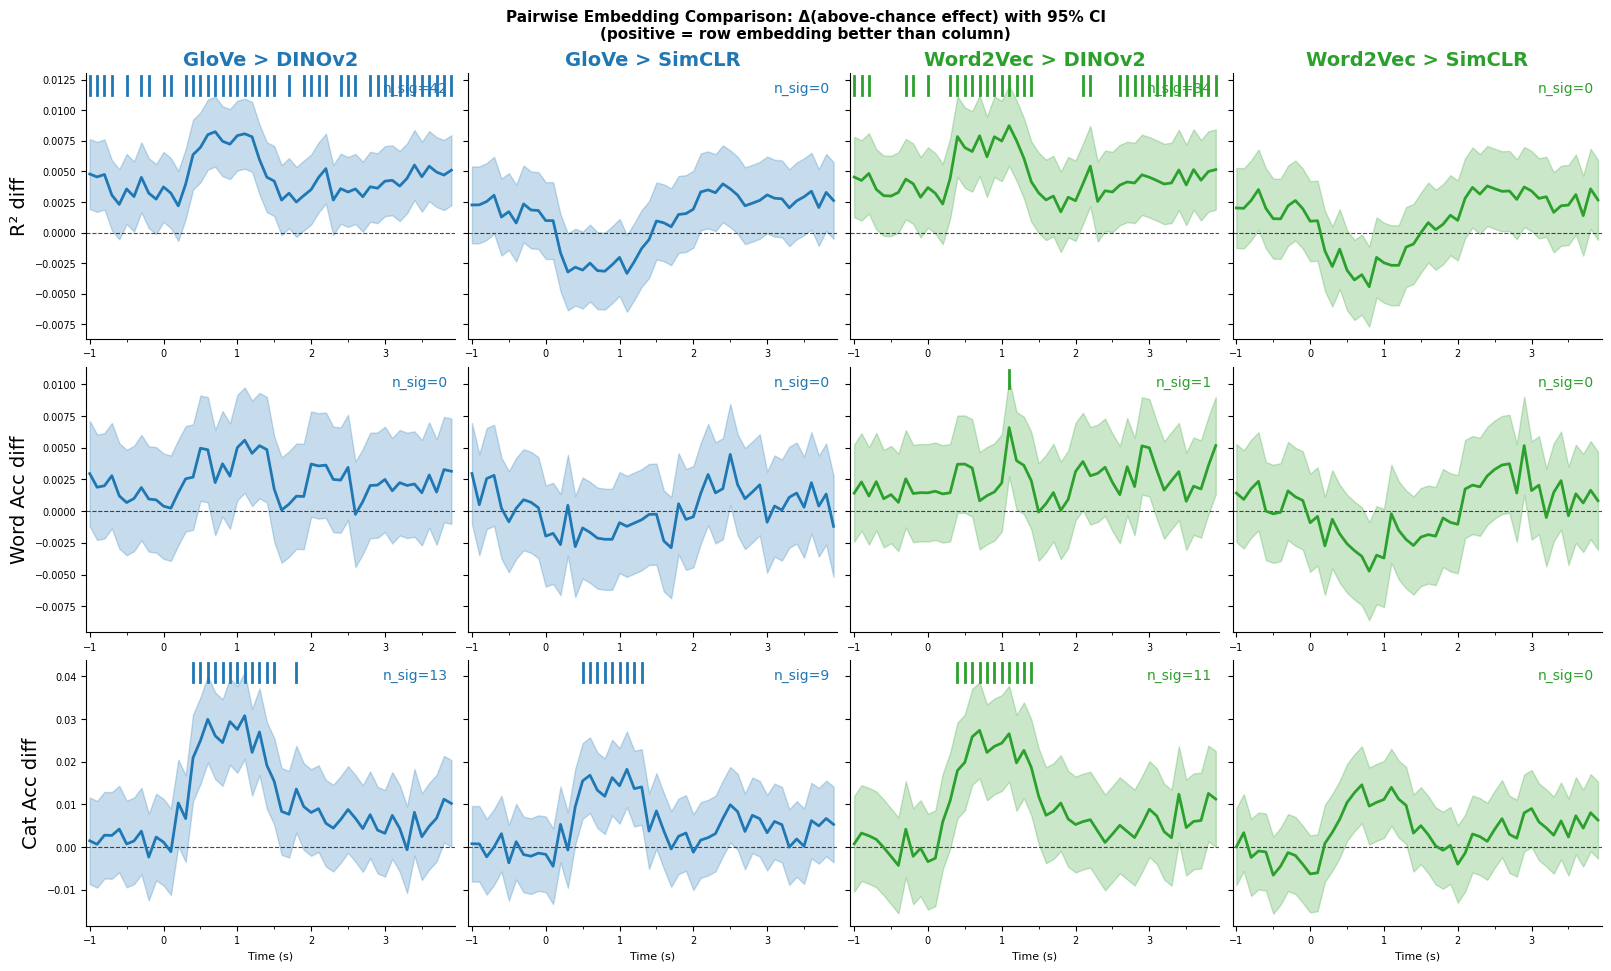

Saved: fig6_pairwise_comparison.png


In [111]:
if len(pair_df) == 0:
    print("No pairwise results to plot. Check COMPARE_PAIRS.")
else:
    PRE_STIM_MS = 1000
    MS_PER_SEC = 1000.0
    half_bin_s = (BIN_SIZE / 2) / MS_PER_SEC

    pairs = pair_df['pair'].unique()
    metric_list = [('r2', 'R² diff'), ('word', 'Word Acc diff'), ('category', 'Cat Acc diff')]
    n_pairs = len(pairs)
    n_met = len(metric_list)

    fig, axes = plt.subplots(
        n_met, n_pairs,
        figsize=(4.0 * n_pairs, 3.2 * n_met),
        sharey='row',
        constrained_layout=True,
    )
    # Ensure axes is always 2-D
    if n_pairs == 1:
        axes = axes[:, np.newaxis]
    if n_met == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle('Pairwise Embedding Comparison: Δ(above-chance effect) with 95% CI\n'
                 '(positive = row embedding better than column)', fontsize=11, fontweight='bold')

    for col_idx, pair_label in enumerate(pairs):
        sub = pair_df[pair_df['pair'] == pair_label]
        emb_a = sub['emb_a'].iloc[0]
        emb_b = sub['emb_b'].iloc[0]
        color_a = EMB_COLORS.get(emb_a, 'steelblue')

        for row_idx, (metric_key, ylabel) in enumerate(metric_list):
            ax = axes[row_idx, col_idx]
            m = sub[sub['metric'] == metric_key].sort_values('bin_index')

            if not len(m):
                ax.set_visible(False)
                continue

            t_s = (m['time_ms'].values - PRE_STIM_MS) / MS_PER_SEC

            # CI band
            ax.fill_between(t_s, m['ci_lower'].values, m['ci_upper'].values,
                            alpha=0.25, color=color_a)
            # Difference line
            ax.plot(t_s, m['diff'].values, color=color_a, lw=2, zorder=3)
            # Zero reference
            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.7)

            # Significance ticks (A > B, p_fdr < ALPHA)
            sig_mask = m['significant'].values
            for t_sig in m.loc[m['significant'], 'time_ms'].values:
                ax.axvline((t_sig - PRE_STIM_MS) / MS_PER_SEC,
                           ymin=0.92, ymax=0.99, color=color_a, lw=2, zorder=5)

            ax.set_xlim(t_s[0] - half_bin_s, t_s[-1] + half_bin_s)
            ax.xaxis.set_major_locator(mticker.MultipleLocator(1.0))
            ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.5))
            ax.tick_params(axis='x', labelsize=7)
            ax.tick_params(axis='y', labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

            if row_idx == 0:
                ax.set_title(pair_label, fontsize=14, fontweight='bold', color=color_a)
            if col_idx == 0:
                ax.set_ylabel(ylabel, fontsize=14)
            if row_idx == n_met - 1:
                ax.set_xlabel('Time (s)', fontsize=8)

            # Annotate n sig bins
            n_sig_b = sig_mask.sum()
            ax.text(0.98, 0.97, f'n_sig={n_sig_b}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=10, color=color_a)

    plt.savefig(MAIN_DIR / 'notebooks' / 'fig6_pairwise_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig6_pairwise_comparison.png")
